In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
import warnings
warnings.simplefilter('ignore')
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import random
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#importing the train dataset
#data1=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Train_Beneficiarydata.csv",encoding='UTF-8')
#data2=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Train_Inpatientdata.csv",encoding='UTF-8')
#data3=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Train_Outpatientdata.csv",encoding='UTF-8')
#data4=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Train.csv",encoding='UTF-8')

#data5=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Test_Beneficiarydata.csv",encoding='UTF-8')
#data6=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Test_Inpatientdata.csv",encoding='UTF-8')
#data7=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Test_Outpatientdata.csv",encoding='UTF-8')
#data8=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Test.csv",encoding='UTF-8')

#importing the train dataset
data1=pd.read_csv("Train_Beneficiarydata.csv",encoding='UTF-8')
data2=pd.read_csv("Train_Inpatientdata.csv",encoding='UTF-8')
data3=pd.read_csv("Train_Outpatientdata.csv",encoding='UTF-8')
data4=pd.read_csv("Train.csv",encoding='UTF-8')

#importing the test dataset
data5=pd.read_csv("Test_Beneficiarydata.csv",encoding='UTF-8')
data6=pd.read_csv("Test_Inpatientdata.csv",encoding='UTF-8')
data7=pd.read_csv("Test_Outpatientdata.csv",encoding='UTF-8')
data8=pd.read_csv("Test.csv",encoding='UTF-8')

In [4]:
#duplicates in datasets

print("duplicates: ",data1.duplicated().sum())
print("duplicates: ",data2.duplicated().sum())
print("duplicates: ",data3.duplicated().sum())
print("duplicates: ",data4.duplicated().sum())

print("duplicates: ",data5.duplicated().sum())
print("duplicates: ",data6.duplicated().sum())
print("duplicates: ",data7.duplicated().sum())
print("duplicates: ",data8.duplicated().sum())

duplicates:  0
duplicates:  0
duplicates:  0
duplicates:  0
duplicates:  0
duplicates:  0
duplicates:  0
duplicates:  0


In [5]:
#shape of train
print("data1: ",data1.shape)
print("data2: ",data2.shape)
print("data3: ",data3.shape)
print("data4: ",data4.shape)

#shape of test
print("data5: ",data5.shape)
print("data6: ",data6.shape)
print("data7: ",data7.shape)
print("data8: ",data8.shape)

data1:  (138556, 25)
data2:  (40474, 30)
data3:  (517737, 27)
data4:  (5410, 2)
data5:  (63968, 25)
data6:  (9551, 30)
data7:  (125841, 27)
data8:  (1353, 1)


In [6]:
data1.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,...,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,...,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,...,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,...,2,1,2,2,2,2,0,0,1790,1200


In [7]:
data2.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [8]:
data3.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


In [9]:
data4.head()

,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


In [10]:
data5.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,...,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,...,1,1,1,2,1,1,36000,3204,60,70
1,BENE11007,1940-09-01,2009-12-01,1,2,0,45,610,12,12,...,2,1,2,1,1,2,0,0,1490,160
2,BENE11010,1936-07-01,NaN,2,1,0,41,30,12,12,...,2,1,1,1,2,2,0,0,1170,660
3,BENE11011,1914-03-01,NaN,2,2,0,1,360,12,12,...,1,1,2,2,1,1,5000,1068,250,320
4,BENE11014,1938-04-01,NaN,2,1,Y,45,780,12,12,...,1,2,1,2,2,2,21260,2136,120,100


In [11]:
data6.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11014,CLM67387,2009-09-09,2009-09-16,PRV57070,9000,PHY317786,PHY427017,NaN,2009-09-09,...,5990,570,41071,4280,4443.0,5849.0,NaN,NaN,NaN,NaN
1,BENE11017,CLM31237,2008-12-25,2009-01-08,PRV54750,14000,PHY314656,PHY426644,NaN,2008-12-25,...,4549,29570,34831,NaN,5551.0,NaN,NaN,NaN,NaN,NaN
2,BENE11026,CLM78930,2009-12-09,2009-12-13,PRV53758,2000,PHY349495,NaN,NaN,2009-12-09,...,78650,7813,4254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11031,CLM56810,2009-06-23,2009-07-06,PRV55825,16000,PHY429538,PHY371893,NaN,2009-06-23,...,4254,41400,5849,41401,8152.0,3320.0,NaN,NaN,NaN,NaN
4,BENE11085,CLM34625,2009-01-20,2009-01-31,PRV52338,19000,PHY397161,NaN,NaN,2009-01-20,...,V6109,7242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
data7.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11001,CLM392397,2009-06-02,2009-06-02,PRV55962,30,PHY347633,NaN,PHY347633,V5832,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
1,BENE11001,CLM430760,2009-06-23,2009-06-23,PRV56112,30,PHY381777,NaN,PHY381777,9594,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
2,BENE11007,CLM233081,2009-03-07,2009-03-07,PRV56979,200,PHY425311,NaN,PHY425311,7248,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11007,CLM496381,2009-07-29,2009-07-29,PRV56573,10,PHY393253,PHY347995,NaN,58889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,5939
4,BENE11007,CLM521391,2009-08-12,2009-08-12,PRV56573,10,PHY417685,NaN,PHY382041,V666,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN


In [13]:
data8.head()

,Provider
0,PRV51002
1,PRV51006
2,PRV51009
3,PRV51010
4,PRV51018


Preproccessing the datasets

In [14]:
#replacing dates with age
data1['DOB'] = pd.to_datetime(data1['DOB'] , format = '%Y-%m-%d')
data1['DOD'] = pd.to_datetime(data1['DOD'],format = '%Y-%m-%d',errors='ignore')
data1['Age'] = round(((data1['DOD'] - data1['DOB']).dt.days)/365)

data5['DOB'] = pd.to_datetime(data5['DOB'] , format = '%Y-%m-%d')
data5['DOD'] = pd.to_datetime(data5['DOD'],format = '%Y-%m-%d',errors='ignore')
data5['Age'] = round(((data5['DOD'] - data5['DOB']).dt.days)/365)

data1.Age.fillna(round(((pd.to_datetime('2009-12-01' , format = '%Y-%m-%d') - data1['DOB']).dt.days)/365),inplace=True)
data5.Age.fillna(round(((pd.to_datetime('2009-12-01' , format = '%Y-%m-%d') - data5['DOB']).dt.days)/365),inplace=True)

In [15]:
data3_columns=data3.columns.tolist()
print(data3_columns)

['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DeductibleAmtPaid', 'ClmAdmitDiagnosisCode']


In [16]:
data2=data2[data3_columns]
data6=data6[data3_columns]

In [17]:
data2.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,...,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,1970,...,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1068.0,7866
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,6186,...,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN,1068.0,6186
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,29623,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1068.0,29590
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,43491,...,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN,1068.0,431
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,042,...,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN,1068.0,78321


In [18]:
data2.shape

(40474, 27)

In [19]:
#concating dataset outpatient and inpatient
data2=pd.concat([data2,data3])
data6=pd.concat([data6,data7])

In [20]:
data2.shape

(558211, 27)

In [21]:
data2.duplicated().sum()

np.int64(0)

In [22]:
data2.columns


Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2',
       'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5',
       'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8',
       'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1',
       'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4',
       'ClmProcedureCode_5', 'ClmProcedureCode_6', 'DeductibleAmtPaid',
       'ClmAdmitDiagnosisCode'],
      dtype='object')

In [23]:
data6.shape

(135392, 27)

In [24]:
#replacing the dates with "Claim Days"
data2['ClaimStartDt'] = pd.to_datetime(data2['ClaimStartDt'] , format = '%Y-%m-%d')
data2['ClaimEndDt'] = pd.to_datetime(data2['ClaimEndDt'],format = '%Y-%m-%d')
data2['ClaimDays'] = ((data2['ClaimEndDt'] - data2['ClaimStartDt']).dt.days)+1

data6['ClaimStartDt'] = pd.to_datetime(data6['ClaimStartDt'] , format = '%Y-%m-%d')
data6['ClaimEndDt'] = pd.to_datetime(data6['ClaimEndDt'],format = '%Y-%m-%d')
data6['ClaimDays'] = ((data6['ClaimEndDt'] - data6['ClaimStartDt']).dt.days)+1


In [25]:
#train data
data1.drop('DOD', axis=1, inplace=True)
data1.drop('DOB', axis=1, inplace=True)

data2.drop('ClaimStartDt', axis=1, inplace=True)
data2.drop('ClaimEndDt', axis=1, inplace=True)

#test data
data5.drop('DOD', axis=1, inplace=True)
data5.drop('DOB', axis=1, inplace=True)

data6.drop('ClaimStartDt', axis=1, inplace=True)
data6.drop('ClaimEndDt', axis=1, inplace=True)

In [26]:
print("data2: ",data2.shape)

data2:  (558211, 26)


In [27]:
print("data6: ",data6.shape)

data6:  (135392, 26)


Handling the missing values

In [28]:
print("**************TRAIN DATA 1 ****************")
print((data1.isna().sum()/len(data1))*100)

**************TRAIN DATA 1 ****************
BeneID                             0.0
Gender                             0.0
Race                               0.0
RenalDiseaseIndicator              0.0
State                              0.0
County                             0.0
NoOfMonths_PartACov                0.0
NoOfMonths_PartBCov                0.0
ChronicCond_Alzheimer              0.0
ChronicCond_Heartfailure           0.0
ChronicCond_KidneyDisease          0.0
ChronicCond_Cancer                 0.0
ChronicCond_ObstrPulmonary         0.0
ChronicCond_Depression             0.0
ChronicCond_Diabetes               0.0
ChronicCond_IschemicHeart          0.0
ChronicCond_Osteoporasis           0.0
ChronicCond_rheumatoidarthritis    0.0
ChronicCond_stroke                 0.0
IPAnnualReimbursementAmt           0.0
IPAnnualDeductibleAmt              0.0
OPAnnualReimbursementAmt           0.0
OPAnnualDeductibleAmt              0.0
Age                                0.0
dtype: float64


In [29]:
print("**************TRAIN DATA 2 ****************")
print((data2.isna().sum()/len(data2))*100)


**************TRAIN DATA 2 ****************
BeneID                      0.000000
ClaimID                     0.000000
Provider                    0.000000
InscClaimAmtReimbursed      0.000000
AttendingPhysician          0.270149
OperatingPhysician         79.497538
OtherPhysician             64.218548
ClmDiagnosisCode_1          1.872589
ClmDiagnosisCode_2         35.041588
ClmDiagnosisCode_3         56.458221
ClmDiagnosisCode_4         70.524407
ClmDiagnosisCode_5         79.949517
ClmDiagnosisCode_6         84.881702
ClmDiagnosisCode_7         88.144805
ClmDiagnosisCode_8         90.425843
ClmDiagnosisCode_9         92.509105
ClmDiagnosisCode_10        99.102490
ClmProcedureCode_1         95.824160
ClmProcedureCode_2         99.016501
ClmProcedureCode_3         99.826410
ClmProcedureCode_4         99.978861
ClmProcedureCode_5         99.998388
ClmProcedureCode_6        100.000000
DeductibleAmtPaid           0.161050
ClmAdmitDiagnosisCode      73.863109
ClaimDays                   0.0

In [30]:
x1=(data2.isna().sum()/len(data2))*100
col_Todrop_data2 = x1[x1> 80].index.tolist()

In [31]:
for i in col_Todrop_data2:
    data2.drop(i, axis=1, inplace=True)
    data6.drop(i, axis=1, inplace=True)

In [32]:
data2.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,DeductibleAmtPaid,ClmAdmitDiagnosisCode,ClaimDays
0,BENE11001,CLM46614,PRV55912,26000,PHY390922,NaN,NaN,1970,4019,5853,7843,2768,1068.0,7866,7
1,BENE11001,CLM66048,PRV55907,5000,PHY318495,PHY318495,NaN,6186,2948,56400,NaN,NaN,1068.0,6186,3
2,BENE11001,CLM68358,PRV56046,5000,PHY372395,NaN,PHY324689,29623,30390,71690,34590,V1581,1068.0,29590,4
3,BENE11011,CLM38412,PRV52405,5000,PHY369659,PHY392961,PHY349768,43491,2762,7843,32723,V1041,1068.0,431,9
4,BENE11014,CLM63689,PRV56614,10000,PHY379376,PHY398258,NaN,042,3051,34400,5856,42732,1068.0,78321,18


In [33]:
data6.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,DeductibleAmtPaid,ClmAdmitDiagnosisCode,ClaimDays
0,BENE11014,CLM67387,PRV57070,9000,PHY317786,PHY427017,NaN,5780,5533,496,V420,40390,1068.0,5789,8
1,BENE11017,CLM31237,PRV54750,14000,PHY314656,PHY426644,NaN,1889,41071,5990,5601,4588,1068.0,5939,15
2,BENE11026,CLM78930,PRV53758,2000,PHY349495,NaN,NaN,4010,78791,60000,41401,V1254,1068.0,4019,5
3,BENE11031,CLM56810,PRV55825,16000,PHY429538,PHY371893,NaN,8208,4168,920,5990,40391,1068.0,8208,14
4,BENE11085,CLM34625,PRV52338,19000,PHY397161,NaN,NaN,29654,V142,78702,30503,V140,1068.0,4279,12


In [34]:
print("**************TRAIN DATA 4 ****************")
print((data4.isna().sum()/len(data2))*100)

**************TRAIN DATA 4 ****************
Provider          0.0
PotentialFraud    0.0
dtype: float64


In [35]:
data2.isna().sum()

BeneID                         0
ClaimID                        0
Provider                       0
InscClaimAmtReimbursed         0
AttendingPhysician          1508
OperatingPhysician        443764
OtherPhysician            358475
ClmDiagnosisCode_1         10453
ClmDiagnosisCode_2        195606
ClmDiagnosisCode_3        315156
ClmDiagnosisCode_4        393675
ClmDiagnosisCode_5        446287
DeductibleAmtPaid            899
ClmAdmitDiagnosisCode     412312
ClaimDays                      0
dtype: int64

In [36]:
d2 = data2.loc[:, data2.isna().sum() > 0]
print(d2.info())

<class 'pandas.core.frame.DataFrame'>
Index: 558211 entries, 0 to 517736
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AttendingPhysician     556703 non-null  object 
 1   OperatingPhysician     114447 non-null  object 
 2   OtherPhysician         199736 non-null  object 
 3   ClmDiagnosisCode_1     547758 non-null  object 
 4   ClmDiagnosisCode_2     362605 non-null  object 
 5   ClmDiagnosisCode_3     243055 non-null  object 
 6   ClmDiagnosisCode_4     164536 non-null  object 
 7   ClmDiagnosisCode_5     111924 non-null  object 
 8   DeductibleAmtPaid      557312 non-null  float64
 9   ClmAdmitDiagnosisCode  145899 non-null  object 
dtypes: float64(1), object(9)
memory usage: 46.8+ MB
None


In [37]:
arrC=['AttendingPhysician','OperatingPhysician','OtherPhysician','ClmDiagnosisCode_1','ClmDiagnosisCode_2','ClmDiagnosisCode_3','ClmDiagnosisCode_4'
                           ,'ClmDiagnosisCode_5','ClmAdmitDiagnosisCode']
arrN=['DeductibleAmtPaid']  #arrC: all catergorical values arrN: all numerical values
data2 = data2.reset_index(drop=True)
knn_imputer = KNNImputer(n_neighbors=5)

chunk_size = 1000  #will impute 1000 at a time since dataset is large it takes time

for i in range(0, len(data2), chunk_size):
    chunk_data = data2.iloc[i:i + chunk_size]
    imputed_chunk = knn_imputer.fit_transform(chunk_data[arrN])

    data2.loc[i:i + chunk_size - 1, arrN] = imputed_chunk

for i in arrC:
    categories = data2[i].dropna().unique()
    data2[i].fillna(random.choice(categories), inplace=True)

In [38]:
data2.isna().sum()

BeneID                    0
ClaimID                   0
Provider                  0
InscClaimAmtReimbursed    0
AttendingPhysician        0
OperatingPhysician        0
OtherPhysician            0
ClmDiagnosisCode_1        0
ClmDiagnosisCode_2        0
ClmDiagnosisCode_3        0
ClmDiagnosisCode_4        0
ClmDiagnosisCode_5        0
DeductibleAmtPaid         0
ClmAdmitDiagnosisCode     0
ClaimDays                 0
dtype: int64

In [39]:
#merging the datset on beneficiary ID
merged_data_1 = pd.merge(data2, data1, on='BeneID', how='left')
test_merged_data_1 = pd.merge(data6, data5, on='BeneID', how='left')

In [40]:
merged_data_1.isna().sum()

BeneID                             0
ClaimID                            0
Provider                           0
InscClaimAmtReimbursed             0
AttendingPhysician                 0
OperatingPhysician                 0
OtherPhysician                     0
ClmDiagnosisCode_1                 0
ClmDiagnosisCode_2                 0
ClmDiagnosisCode_3                 0
ClmDiagnosisCode_4                 0
ClmDiagnosisCode_5                 0
DeductibleAmtPaid                  0
ClmAdmitDiagnosisCode              0
ClaimDays                          0
Gender                             0
Race                               0
RenalDiseaseIndicator              0
State                              0
County                             0
NoOfMonths_PartACov                0
NoOfMonths_PartBCov                0
ChronicCond_Alzheimer              0
ChronicCond_Heartfailure           0
ChronicCond_KidneyDisease          0
ChronicCond_Cancer                 0
ChronicCond_ObstrPulmonary         0
C

In [41]:
merged_data_1.shape

(558211, 38)

In [42]:
test_merged_data_1.shape

(135392, 38)

In [43]:
#merging the dataset on Provider
Final_data = pd.merge(merged_data_1, data4, on='Provider', how='right')
Final_data_test = pd.merge(test_merged_data_1, data8, on='Provider', how='right')

In [44]:
Final_data.shape

(558211, 39)

In [45]:
Final_data_test.shape

(135392, 38)

In [46]:
Final_data.isna().sum()

BeneID                             0
ClaimID                            0
Provider                           0
InscClaimAmtReimbursed             0
AttendingPhysician                 0
OperatingPhysician                 0
OtherPhysician                     0
ClmDiagnosisCode_1                 0
ClmDiagnosisCode_2                 0
ClmDiagnosisCode_3                 0
ClmDiagnosisCode_4                 0
ClmDiagnosisCode_5                 0
DeductibleAmtPaid                  0
ClmAdmitDiagnosisCode              0
ClaimDays                          0
Gender                             0
Race                               0
RenalDiseaseIndicator              0
State                              0
County                             0
NoOfMonths_PartACov                0
NoOfMonths_PartBCov                0
ChronicCond_Alzheimer              0
ChronicCond_Heartfailure           0
ChronicCond_KidneyDisease          0
ChronicCond_Cancer                 0
ChronicCond_ObstrPulmonary         0
C

In [47]:
Final_data.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,BENE36012,CLM58316,PRV51001,36000,PHY340163,PHY387978,PHY338158,29650,2971,3051,...,1,2,2,1,36000,1068,3520,140,69.0,No
1,BENE38773,CLM52334,PRV51001,12000,PHY346762,PHY387978,PHY338158,0388,5849,2841,...,2,2,2,2,95000,2136,2270,900,72.0,No
2,BENE98831,CLM36844,PRV51001,3000,PHY383193,PHY387978,PHY338158,56211,5533,0088,...,1,2,1,2,3000,1068,0,0,75.0,No
3,BENE102690,CLM49733,PRV51001,42000,PHY383193,PHY378091,PHY389113,4241,42731,4168,...,1,2,1,2,143800,4272,880,70,80.0,No
4,BENE152088,CLM37205,PRV51001,4000,PHY402229,PHY329739,PHY338158,85222,2724,3310,...,1,2,1,1,111710,4272,80,70,96.0,No


In [48]:
Final_data.nunique()

BeneID                             138556
ClaimID                            558211
Provider                             5410
InscClaimAmtReimbursed                438
AttendingPhysician                  82063
OperatingPhysician                  35315
OtherPhysician                      46457
ClmDiagnosisCode_1                  10450
ClmDiagnosisCode_2                   5300
ClmDiagnosisCode_3                   4756
ClmDiagnosisCode_4                   4359
ClmDiagnosisCode_5                   3970
DeductibleAmtPaid                      18
ClmAdmitDiagnosisCode                4098
ClaimDays                              37
Gender                                  2
Race                                    4
RenalDiseaseIndicator                   2
State                                  52
County                                314
NoOfMonths_PartACov                    13
NoOfMonths_PartBCov                    13
ChronicCond_Alzheimer                   2
ChronicCond_Heartfailure          

In [49]:
#Encoding the dataset
from sklearn.preprocessing import LabelEncoder
arr1=Final_data.columns.tolist()
arr1.remove("PotentialFraud")
#encoding using LabelEncoder
for i in arr1:
    sampler1=LabelEncoder()
    sampler2=LabelEncoder()
    Final_data[i]=sampler1.fit_transform(Final_data[i])
    Final_data_test[i]=sampler2.fit_transform(Final_data_test[i])

Final_data['PotentialFraud']=Final_data['PotentialFraud'].map({'Yes':1,'No':0})


In [50]:
Final_data_test.shape

(135392, 38)

In [51]:
Final_data.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,78757,402690,0,361,19481,22154,10271,2214,992,946,...,0,1,1,0,1947,1,358,14,43,0
1,81332,349611,0,298,23883,22154,10271,192,2566,717,...,1,1,1,1,2929,16,233,92,46,0
2,137459,212548,0,158,48046,22154,10271,4972,2403,4,...,0,1,0,1,138,1,6,0,49,0
3,2520,326625,0,367,48046,19353,29577,4020,1896,1597,...,0,1,0,1,2995,43,94,7,54,0
4,52713,215768,0,183,60753,5447,10271,8267,731,1046,...,0,1,0,0,2961,43,14,7,70,0


<Axes: >

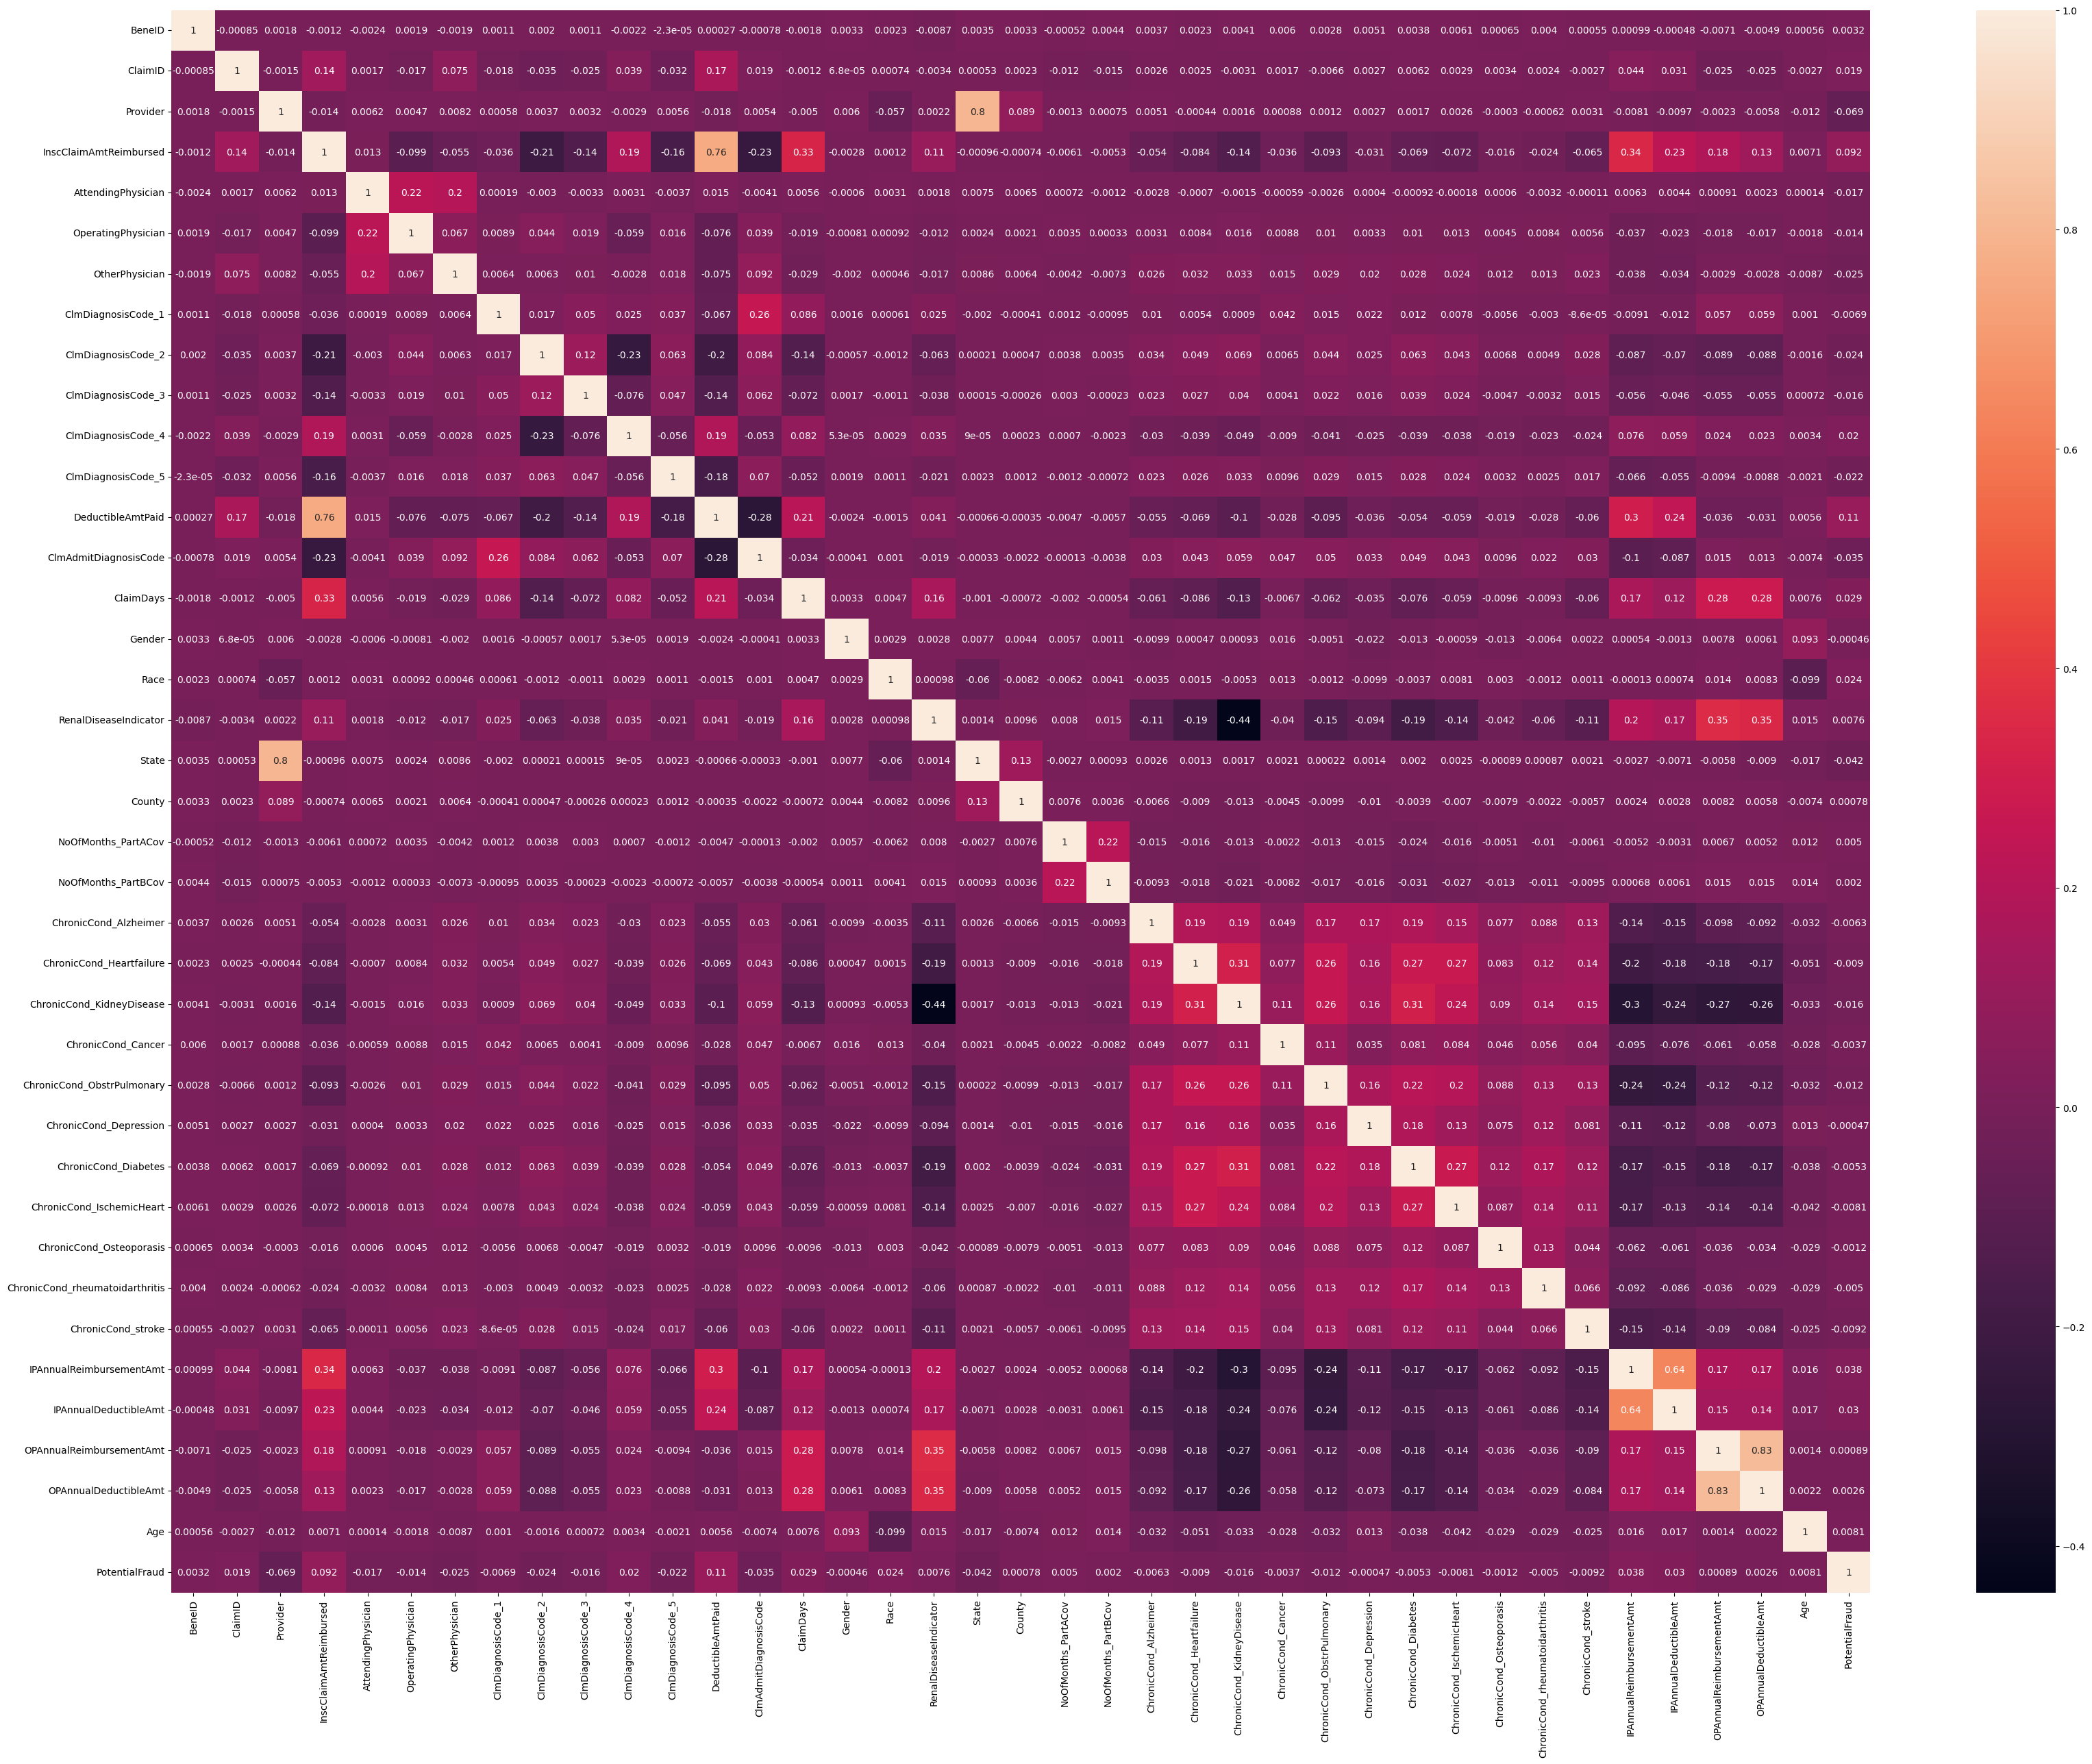

In [52]:
plt.figure(figsize=(40,30))
sns.heatmap(Final_data.corr(),annot=True)

In [53]:
Final_data.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,78757,402690,0,361,19481,22154,10271,2214,992,946,...,0,1,1,0,1947,1,358,14,43,0
1,81332,349611,0,298,23883,22154,10271,192,2566,717,...,1,1,1,1,2929,16,233,92,46,0
2,137459,212548,0,158,48046,22154,10271,4972,2403,4,...,0,1,0,1,138,1,6,0,49,0
3,2520,326625,0,367,48046,19353,29577,4020,1896,1597,...,0,1,0,1,2995,43,94,7,54,0
4,52713,215768,0,183,60753,5447,10271,8267,731,1046,...,0,1,0,0,2961,43,14,7,70,0


In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_val_score
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [55]:
print((Final_data['PotentialFraud'].value_counts()/len(Final_data))*100)

PotentialFraud
0    61.878931
1    38.121069
Name: count, dtype: float64


In [56]:
Final_data.shape

(558211, 39)

In [57]:
Final_data.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,78757,402690,0,361,19481,22154,10271,2214,992,946,...,0,1,1,0,1947,1,358,14,43,0
1,81332,349611,0,298,23883,22154,10271,192,2566,717,...,1,1,1,1,2929,16,233,92,46,0
2,137459,212548,0,158,48046,22154,10271,4972,2403,4,...,0,1,0,1,138,1,6,0,49,0
3,2520,326625,0,367,48046,19353,29577,4020,1896,1597,...,0,1,0,1,2995,43,94,7,54,0
4,52713,215768,0,183,60753,5447,10271,8267,731,1046,...,0,1,0,0,2961,43,14,7,70,0


Resampling and standardising the dataset

In [58]:
X1=Final_data.iloc[:,:-1]
y1=Final_data.iloc[:,-1]

In [59]:
X1_resampled,y1_resampled=RandomUnderSampler().fit_resample(X1,y1)

In [60]:
from collections import Counter
print(Counter(y1_resampled))


Counter({0: 212796, 1: 212796})


In [61]:
X1_resampled.shape

(425592, 38)

In [62]:
y1_resampled.shape

(425592,)

In [63]:
X1_standardised=StandardScaler().fit_transform(X1_resampled)

In [64]:
X1_standardised.shape

(425592, 38)

In [65]:
y1_resampled.shape

(425592,)

In [66]:
X1_proccessed=pd.DataFrame(X1_standardised,columns=arr1)
y1_proccessed=pd.DataFrame(y1_resampled,columns=['PotentialFraud'])

X1_proccessed = X1_proccessed.reset_index(drop=True)
y1_proccessed = y1_proccessed.reset_index(drop=True)

Final_data_proccessed=pd.concat([X1_proccessed,y1_proccessed],axis=1)


In [67]:
Final_data_proccessed.shape

(425592, 39)

In [68]:
Final_data_proccessed.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,...,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,-0.793814,1.190199,1.687236,-0.146545,-0.660313,0.190557,-1.071685,0.619205,0.835792,-0.202946,...,-0.562284,-1.464505,0.673870,0.337624,-0.492526,-0.323353,-0.558027,-0.199056,-1.213508,0
1,0.658450,0.394517,-0.256665,0.268532,1.170217,0.190557,-0.437275,-0.075506,-1.637494,0.157922,...,-0.562284,-1.464505,0.673870,0.337624,-0.492526,-0.323353,0.591159,-0.468613,-0.522278,0
2,1.090360,1.393526,-0.806801,-0.547786,-0.323318,0.190557,-0.437275,1.514127,-0.912682,0.157922,...,-0.562284,-1.464505,-1.483966,0.337624,0.280228,-0.216299,-0.041726,0.120418,-1.443917,0
3,-0.662549,0.611182,1.371764,-0.547786,-1.586523,0.190557,-0.437275,-0.456174,0.891156,0.157922,...,-0.562284,0.682824,0.673870,0.337624,1.514462,1.389514,-0.378155,0.080484,0.629771,0
4,-0.913808,1.159490,1.157787,-0.354083,0.850979,0.190557,-0.437275,-0.486306,-0.927370,0.157922,...,-0.562284,-1.464505,0.673870,0.337624,-0.492526,-0.323353,-0.291549,-0.069270,-1.904737,0


In [69]:
Final_data_proccessed.isna().sum()

BeneID                             0
ClaimID                            0
Provider                           0
InscClaimAmtReimbursed             0
AttendingPhysician                 0
OperatingPhysician                 0
OtherPhysician                     0
ClmDiagnosisCode_1                 0
ClmDiagnosisCode_2                 0
ClmDiagnosisCode_3                 0
ClmDiagnosisCode_4                 0
ClmDiagnosisCode_5                 0
DeductibleAmtPaid                  0
ClmAdmitDiagnosisCode              0
ClaimDays                          0
Gender                             0
Race                               0
RenalDiseaseIndicator              0
State                              0
County                             0
NoOfMonths_PartACov                0
NoOfMonths_PartBCov                0
ChronicCond_Alzheimer              0
ChronicCond_Heartfailure           0
ChronicCond_KidneyDisease          0
ChronicCond_Cancer                 0
ChronicCond_ObstrPulmonary         0
C

In [70]:
print("duplicates: ",Final_data_proccessed.duplicated().sum())

duplicates:  0


applying Feature selection methodology using _feature_importances scores 

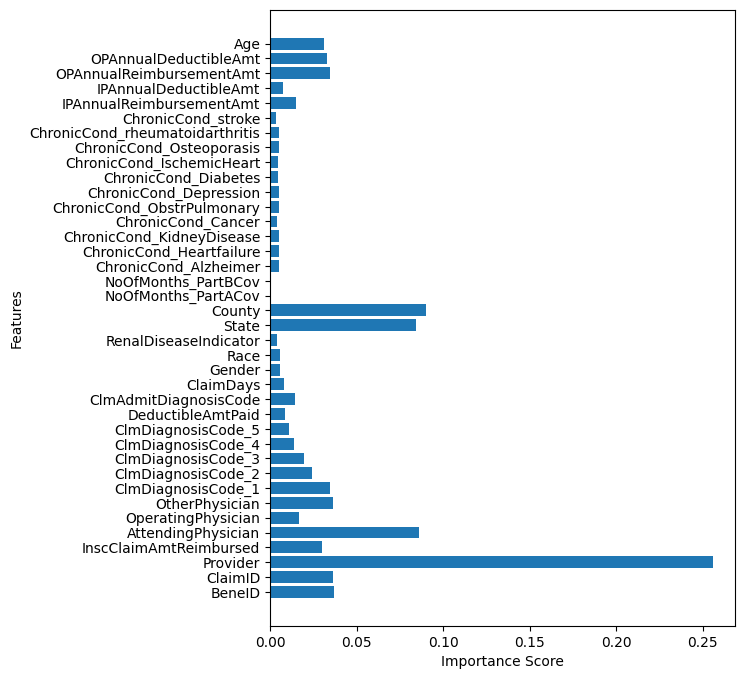

In [71]:
X1=Final_data_proccessed.iloc[:,:-1]
y1=Final_data_proccessed.iloc[:,-1]

rf1 = RandomForestClassifier(n_estimators=60,random_state=42)



rf1.fit(X1,y1)

plt.figure(figsize=(6,8))
feature_names = list(arr1)
plt.barh(feature_names, rf1.feature_importances_)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [72]:
arr=rf1.feature_importances_.tolist()
arr.sort(reverse=True)
print(arr)

[0.2559009926473545, 0.08996821019866726, 0.08636737854044439, 0.08462334512559017, 0.03718079116099099, 0.036599339908767035, 0.03619399657773559, 0.0349184361345193, 0.03479121637966694, 0.03299388692928823, 0.031026962156763302, 0.029816574678032396, 0.024195652173279104, 0.019863956118093627, 0.01679163535206381, 0.014944398145652129, 0.014558931156148326, 0.014111028980593581, 0.011196122107883226, 0.008623679312818709, 0.007838997107111428, 0.007328417586303927, 0.0058529587271506514, 0.005626824247311637, 0.005456809190548294, 0.0053547797714702345, 0.005348153605337577, 0.005263217204552597, 0.005175723168405277, 0.004950668820713133, 0.004909533955228439, 0.004839803503514777, 0.004633745015524004, 0.004099874944720432, 0.003955313458090091, 0.003379085607397051, 0.000739689313503043, 0.0005798709887645968]


In [73]:
threshold = 0.02
selected_columns = np.where(rf1.feature_importances_ > threshold)[0]

# Get the names of selected features
selected_features_1 = Final_data_proccessed.columns[selected_columns]  

print("Selected features:",selected_features_1)

Selected features: Index(['BeneID', 'ClaimID', 'Provider', 'InscClaimAmtReimbursed',
       'AttendingPhysician', 'OtherPhysician', 'ClmDiagnosisCode_1',
       'ClmDiagnosisCode_2', 'State', 'County', 'OPAnnualReimbursementAmt',
       'OPAnnualDeductibleAmt', 'Age'],
      dtype='object')


In [74]:

X1=Final_data_proccessed.loc[:,selected_features_1]
Final_data_test=Final_data_test.loc[:,selected_features_1]
y1=pd.DataFrame(y1,columns=['PotentialFraud'])

New_data=pd.concat([X1,y1],axis=1)

New dataset of most important features 

In [75]:
New_data.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,State,County,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age,PotentialFraud
0,-0.793814,1.190199,1.687236,-0.146545,-0.660313,-1.071685,0.619205,0.835792,1.619210,-0.969882,-0.558027,-0.199056,-1.213508,0
1,0.658450,0.394517,-0.256665,0.268532,1.170217,-0.437275,-0.075506,-1.637494,-0.271750,-1.140724,0.591159,-0.468613,-0.522278,0
2,1.090360,1.393526,-0.806801,-0.547786,-0.323318,-0.437275,1.514127,-0.912682,-0.744489,-0.827512,-0.041726,0.120418,-1.443917,0
3,-0.662549,0.611182,1.371764,-0.547786,-1.586523,-0.437275,-0.456174,0.891156,1.281538,-0.115667,-0.378155,0.080484,0.629771,0
4,-0.913808,1.159490,1.157787,-0.354083,0.850979,-0.437275,-0.486306,-0.927370,1.214004,1.436156,-0.291549,-0.069270,-1.904737,0


In [76]:
New_data.isna().sum()

BeneID                      0
ClaimID                     0
Provider                    0
InscClaimAmtReimbursed      0
AttendingPhysician          0
OtherPhysician              0
ClmDiagnosisCode_1          0
ClmDiagnosisCode_2          0
State                       0
County                      0
OPAnnualReimbursementAmt    0
OPAnnualDeductibleAmt       0
Age                         0
PotentialFraud              0
dtype: int64

In [77]:
New_data.shape

(425592, 14)

In [78]:
Final_data_test.shape

(135392, 13)

In [79]:
Final_data_test.head()

,BeneID,ClaimID,Provider,InscClaimAmtReimbursed,AttendingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,State,County,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,Age
0,15420,3909,0,10,18781,10161,3682,2591,0,81,133,59,49
1,18170,10585,0,4,15503,12096,5816,3360,0,18,104,92,63
2,18170,47430,0,7,7224,12096,7887,3301,0,18,104,92,63
3,18170,80208,0,10,9669,12096,3262,3610,0,18,104,92,63
4,21235,31925,0,40,15879,1927,513,3610,0,87,154,73,23


In [80]:
#splisting the datset into train and test
X2=New_data.iloc[:,:-1]
y2=New_data.iloc[:,-1]
X_train,X_test,y_train,y_test=train_test_split(X2,y2,test_size=0.3,random_state=42)


Decision Tree Classifier and it's results

In [81]:
dtc=DecisionTreeClassifier()

scores = cross_val_score(dtc, X_train, y_train, cv=5, scoring='accuracy')
# Printing the scores
print("Accuracy scores:", scores)
print("the Training accuracy:", scores.mean()*100)

dtc.fit(X_train,y_train)
predict2=dtc.predict(X_test)

print("Accuracy: ",accuracy_score(y_test,predict2)*100)
print("the f1 score is : ",f1_score(y_test, predict2)*100)  #f1 Score
print("classification report:\n ",classification_report(y_test,predict2)) #Classification Report

Accuracy scores: [0.98298172 0.9848111  0.98355236 0.98338452 0.98331711]
the Training accuracy: 98.36093627951234
Accuracy:  98.61056720813296
the f1 score is :  98.61098061323563
classification report:
                precision    recall  f1-score   support

           0       0.99      0.99      0.99     63868
           1       0.99      0.99      0.99     63810

    accuracy                           0.99    127678
   macro avg       0.99      0.99      0.99    127678
weighted avg       0.99      0.99      0.99    127678



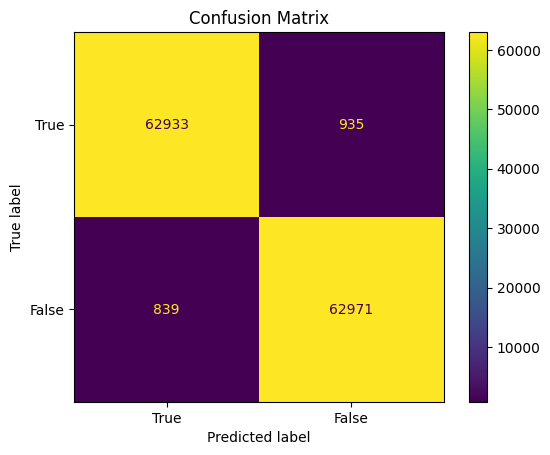

In [82]:
#confusion matrix

cnf_matrix = confusion_matrix(y_test,predict2)
ConfusionMatrixDisplay(confusion_matrix  = cnf_matrix,display_labels = [True, False]).plot()
plt.title('Confusion Matrix')
plt.show()

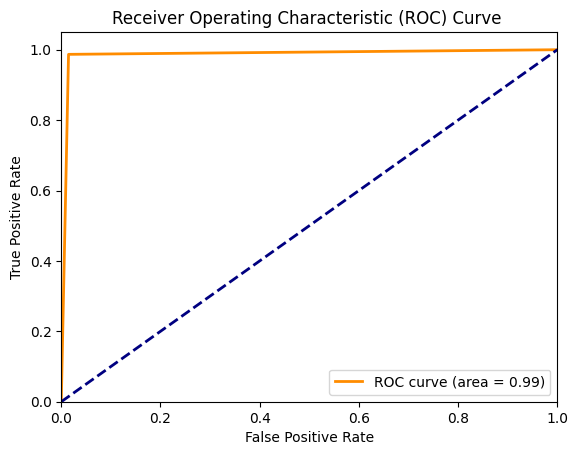

In [83]:
#AUC/ROC curve
y_pred_proba = dtc.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plotting ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve ')
plt.legend(loc="lower right")
plt.show()

RandomForest Classifier and it's results

In [84]:
rf2=RandomForestClassifier(n_estimators=60,random_state=42)

scores = cross_val_score(rf2, X_train, y_train, cv=5, scoring='accuracy')
# Printing the scores
print("Accuracy scores:", scores)
print("the Training accuracy:", scores.mean()*100)

rf2.fit(X_train,y_train)
predict2=rf2.predict(X_test)

print("Accuracy: ",accuracy_score(y_test,predict2)*100)
print("the f1 score is : ",f1_score(y_test, predict2)*100)  #f1 Score
print("classification report:\n ",classification_report(y_test,predict2)) #Classification Report

Accuracy scores: [0.9126093  0.91485826 0.91395197 0.91135055 0.91292672]
the Training accuracy: 91.31393616525614
Accuracy:  92.36673506790521
the f1 score is :  92.21490877719908
classification report:
                precision    recall  f1-score   support

           0       0.91      0.94      0.93     63868
           1       0.94      0.90      0.92     63810

    accuracy                           0.92    127678
   macro avg       0.92      0.92      0.92    127678
weighted avg       0.92      0.92      0.92    127678



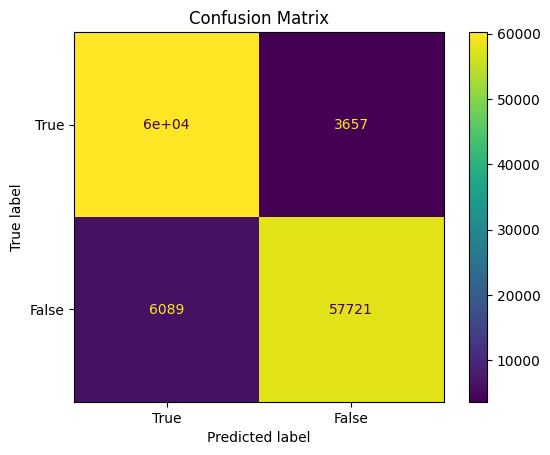

In [85]:
#confusion matrix

cnf_matrix = confusion_matrix(y_test,predict2)
ConfusionMatrixDisplay(confusion_matrix  = cnf_matrix,display_labels = [True, False]).plot()
plt.title('Confusion Matrix')
plt.show()

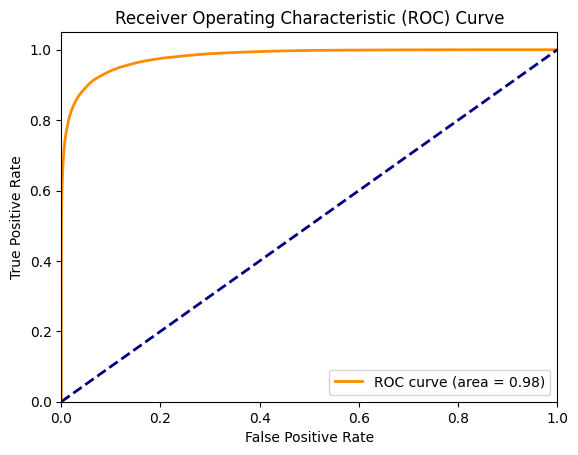

In [86]:
#AUC/ROC curve
y_pred_proba = rf2.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plotting ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Logistic Regression and it's results

In [87]:
lr=LogisticRegression()
lr.fit(X_train,y_train)

scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='accuracy')
# Printing the scores
print("Accuracy scores:", scores)
print("the Training accuracy:", scores.mean()*100)

predict2=lr.predict(X_test)

print("Accuracy: ",accuracy_score(y_test,predict2)*100)
print("the f1 score is : ",f1_score(y_test, predict2)*100)  #f1 Score
print("classification report:\n ",classification_report(y_test,predict2)) #Classification Report

Accuracy scores: [0.54478626 0.54161422 0.54124499 0.54416528 0.54261354]
the Training accuracy: 54.2884858478227
Accuracy:  54.403264462162625
the f1 score is :  52.097784140932916
classification report:
                precision    recall  f1-score   support

           0       0.54      0.59      0.56     63868
           1       0.55      0.50      0.52     63810

    accuracy                           0.54    127678
   macro avg       0.54      0.54      0.54    127678
weighted avg       0.54      0.54      0.54    127678



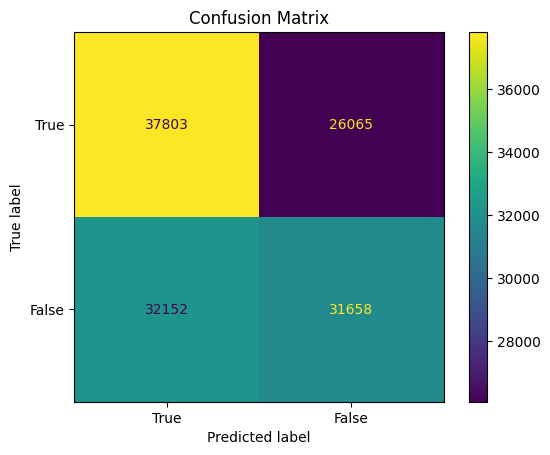

In [88]:
#confusion matrix
cnf_matrix = confusion_matrix(y_test,predict2)
ConfusionMatrixDisplay(confusion_matrix  = cnf_matrix,display_labels = [True, False]).plot()
plt.title('Confusion Matrix')
plt.show()

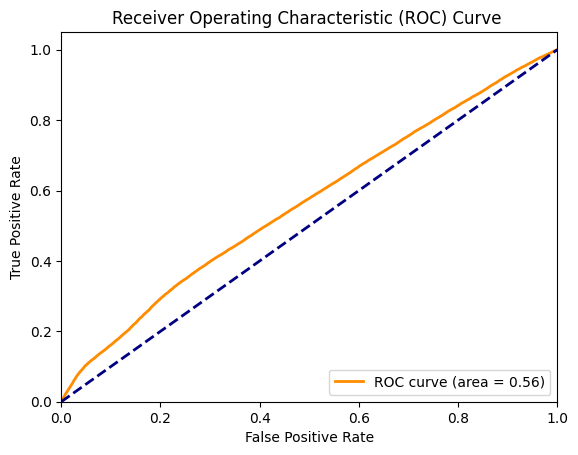

In [89]:
#AUC/ROC curve
y_pred_proba = lr.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plotting ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve ')
plt.legend(loc="lower right")
plt.show()

Using models to have real time predictions using test data

In [90]:
pred=dtc.predict(Final_data_test)
c=0
for i in pred:
    if i==1:
        c+=1
print("Fraud: ",c)
print("Genuiene: ",len(pred)-c)

Fraud:  102
Genuiene:  135290


In [91]:
pred1=rf2.predict(Final_data_test)
c=0
for i in pred1:
    if i==1:
        c+=1
print("Fraud: ",c)
print("Genuiene: ",len(pred1)-c)

Fraud:  172
Genuiene:  135220


In [92]:
pred2=lr.predict(Final_data_test)
c=0
for i in pred2:
    if i==1:
        c+=1
print("Fraud: ",c)
print("Genuiene: ",len(pred2)-c)

Fraud:  101838
Genuiene:  33554
